In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler


dipole = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/dipole_moments.csv'))
structures = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/structures.csv'))
scalar_coupling_contributions = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/scalar_coupling_contributions.csv'))
magnetic_shielding_tensors = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/magnetic_shielding_tensors.csv'))
mulliken_charges = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/mulliken_charges.csv'))
potential_energy = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/potential_energy.csv'))
samples = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/sample_submission.csv'))
test = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/test.csv'))
train = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/train.csv'))


In [5]:
first_coord_data = train.merge(structures, left_on=["molecule_name", "atom_index_0"], right_on=["molecule_name", "atom_index"],how="left")
first_coord_data  = first_coord_data .rename(columns={"atom": "atom_0", "x": "x0", "y": "y0", "z": "z0"}).drop("atom_index", axis=1)
train = first_coord_data.merge(structures, left_on=["molecule_name", "atom_index_1"], right_on=["molecule_name", "atom_index"],how="left",).drop("atom_index", axis=1)
train = train.rename(columns={"atom": "atom_1", "x": "x1", "y": "y1", "z": "z1"})
train.head()

,id,molecule_name,atom_index_0,atom_index_1,type,scalar_coupling_constant,atom_0,x0,y0,z0,atom_1,x1,y1,z1
0,0,dsgdb9nsd_000001,1,0,1JHC,84.8076,H,0.002150,-0.006031,0.001976,C,-0.012698,1.085804,0.008001
1,1,dsgdb9nsd_000001,1,2,2JHH,-11.2570,H,0.002150,-0.006031,0.001976,H,1.011731,1.463751,0.000277
2,2,dsgdb9nsd_000001,1,3,2JHH,-11.2548,H,0.002150,-0.006031,0.001976,H,-0.540815,1.447527,-0.876644
3,3,dsgdb9nsd_000001,1,4,2JHH,-11.2543,H,0.002150,-0.006031,0.001976,H,-0.523814,1.437933,0.906397
4,4,dsgdb9nsd_000001,2,0,1JHC,84.8074,H,1.011731,1.463751,0.000277,C,-0.012698,1.085804,0.008001


In [7]:
train.shape

(4659076, 14)

In [ ]:
# train = train.merge(scalar_coupling_contributions, on=['molecule_name', 'atom_index_0', 'atom_index_1'], how='left')
# train = train.merge(potential_energy, on='molecule_name', how='left')
# train = train.merge(dipole, on='molecule_name', how='left')
# train = train.merge(mulliken_charges, left_on=['molecule_name', 'atom_index_0'], right_on=['molecule_name', 'atom_index'], how='left')

In [8]:
train["dist"] = np.sqrt((train["x1"] - train["x0"]) ** 2+ (train["y1"] - train["y0"]) ** 2 + (train["z1"] - train["z0"]) ** 2)
train["inv_dist"] = 1.0 / train["dist"]
train["inv_dist2"] = 1.0 / (train["dist"] ** 2)
train["inv_dist3"] = 1.0 / (train["dist"] ** 3)
train["inv_dist6"] = 1.0 / (train["dist"] ** 6)
electronegativity = {"H": 2.20, "C": 2.55, "N": 3.04, "O": 3.44, "F": 3.98}

train["en_0"] = train["atom_0"].map(electronegativity)
train["en_1"] = train["atom_1"].map(electronegativity)
train["en_diff"] = np.abs(train["en_0"] - train["en_1"])


In [9]:
train.shape

(4659076, 22)

In [10]:
from sklearn.model_selection import GroupKFold
splits=GroupKFold(n_splits=5)
train['fold']=-999
for fold, (train_idx, val_idx) in enumerate(splits.split(train, groups=train['molecule_name'])):
    train.loc[val_idx, 'fold'] = fold

In [11]:
train_fold = train[train['fold'] != 0].copy()
val_fold = train[train['fold'] == 0].copy()

In [20]:
import torch
import torch.nn as nn

class LearnableScale(nn.Module):
    def __init__(self, in_features):
        super(LearnableScale, self).__init__()
        self.gamma = nn.Parameter(torch.ones(in_features))

    def forward(self, x):
        return x * self.gamma

In [21]:
from torch.optim import Optimizer

class CustomSGD(Optimizer):

    def __init__(self, params, lr=1e-3, weight_decay=0.0):
        defaults = dict(lr=lr, weight_decay=weight_decay)
        super(CustomSGD, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group['lr']
            wd = group['weight_decay']

            for p in group['params']:
                if p.grad is None:
                    continue
                d_p = p.grad

                #Weight Decay (L2 Regularization)
                if wd != 0:
                    d_p = d_p.add(p, alpha=wd)
                p.add_(d_p, alpha=-lr)

        return loss

In [28]:
class DeepMLP(nn.Module):
    def __init__(self, input_dim=22):
        super(DeepMLP, self).__init__()
        self.scale_layer = LearnableScale(input_dim)
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.scale_layer(x)
        return self.layers(x)
device = torch.device('cpu')
print(f"Total parameters: {sum(p.numel() for p in model.parameters()) / 1e6}")

Total parameters: 0.051677


In [26]:
feature_cols = [ c for c in train_fold.columns if c not in ['id', 'molecule_name', 'target', 'scalar_coupling_constant', 'fold']]

X_train_encoded = pd.get_dummies(train_fold[feature_cols])
X_val_encoded = pd.get_dummies(val_fold[feature_cols])
X_train_encoded, X_val_encoded = X_train_encoded.align( X_val_encoded, join='left', axis=1, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded.values)
X_val_scaled = scaler.transform(X_val_encoded.values)

target_col = 'scalar_coupling_constant'
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor( train_fold[target_col].values, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor( val_fold[target_col].values, dtype=torch.float32).unsqueeze(1)

In [29]:
model = DeepMLP(input_dim=X_train_tensor.shape[1]).to(device)
optimizer = CustomSGD(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [30]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2048, shuffle=False)

In [31]:
import wandb

run = wandb.init( project="champs-scalar-coupling",
    name="deep-mlp-custom-sgd",
    config={
        "learning_rate": 1e-3,
        "epochs": 50,
        "batch_size": 2048,
        "architecture": "DeepMLP",
        "optimizer": "CustomSGD"}
)

wandb.watch(model, log="all", log_freq=100)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: aakhlamova (aakhlamova-kyiv-school-of-economics) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [34]:
epochs=50
criterion = nn.L1Loss()

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

    train_loss = running_train_loss / len(train_loader.dataset)

    model.eval()
    val_preds = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch)
            val_preds.append(preds.numpy())

    val_preds = np.concatenate(val_preds).reshape(-1)
    y_val_true = y_val_tensor.numpy().reshape(-1)
    
    val_loss = np.mean(np.abs(val_preds - y_val_true))
    val_df_eval = pd.DataFrame({  'type': val_fold['type'].values, 'error': np.abs(val_preds - y_val_true) } )

    mae_per_type = val_df_eval.groupby('type')['error'].mean()
    log_mae_score = np.log(mae_per_type).mean()

    print(f'Epoch {epoch+1:02d} | Train MAE: {train_loss:.4f} | Val MAE: {val_loss:.4f} | Log MAE: {log_mae_score:.4f}')

    wandb.log(
        {
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_mae': val_loss,
            'log_mae_score': log_mae_score
        }
    )

wandb.finish()

Epoch 01 | Train MAE: 15.2549 | Val MAE: 10.7831 | Log MAE: 1.6656
Epoch 02 | Train MAE: 6.2418 | Val MAE: 3.8565 | Log MAE: 1.2160
Epoch 03 | Train MAE: 4.4631 | Val MAE: 3.6512 | Log MAE: 1.1436
Epoch 04 | Train MAE: 4.2913 | Val MAE: 3.6160 | Log MAE: 1.1368
Epoch 05 | Train MAE: 4.1818 | Val MAE: 3.5522 | Log MAE: 1.1282
Epoch 06 | Train MAE: 4.0808 | Val MAE: 3.4726 | Log MAE: 1.1097
Epoch 07 | Train MAE: 3.8948 | Val MAE: 3.3194 | Log MAE: 1.0622
Epoch 08 | Train MAE: 3.6411 | Val MAE: 3.0806 | Log MAE: 1.0128
Epoch 09 | Train MAE: 3.5090 | Val MAE: 2.8753 | Log MAE: 0.9437
Epoch 10 | Train MAE: 3.4240 | Val MAE: 2.8828 | Log MAE: 0.9547
Epoch 11 | Train MAE: 3.3509 | Val MAE: 2.8323 | Log MAE: 0.9337
Epoch 12 | Train MAE: 3.3034 | Val MAE: 2.8285 | Log MAE: 0.9281
Epoch 13 | Train MAE: 3.2621 | Val MAE: 2.8234 | Log MAE: 0.9183
Epoch 14 | Train MAE: 3.2231 | Val MAE: 2.7701 | Log MAE: 0.8986
Epoch 15 | Train MAE: 3.1955 | Val MAE: 2.7726 | Log MAE: 0.8946
Epoch 16 | Train MAE: 3

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
log_mae_score,█▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_mae,█▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,50
log_mae_score,0.86404
train_loss,2.83595
val_mae,2.71592


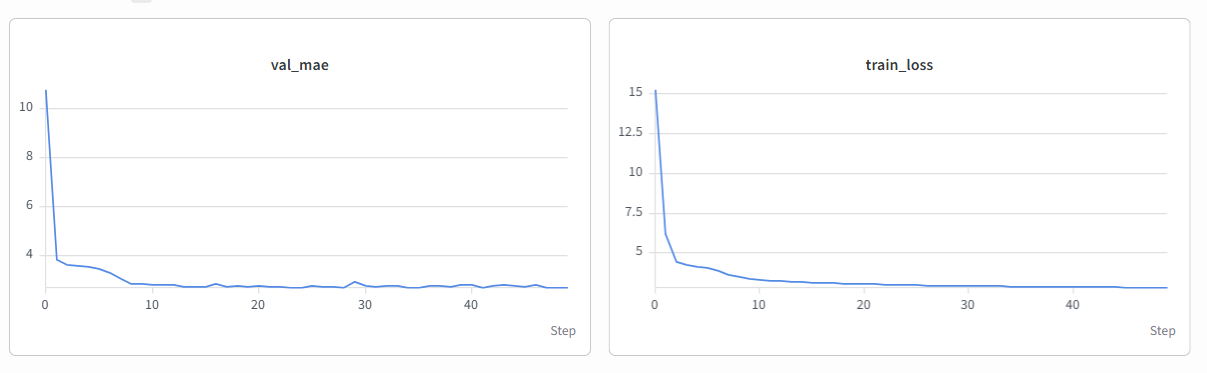

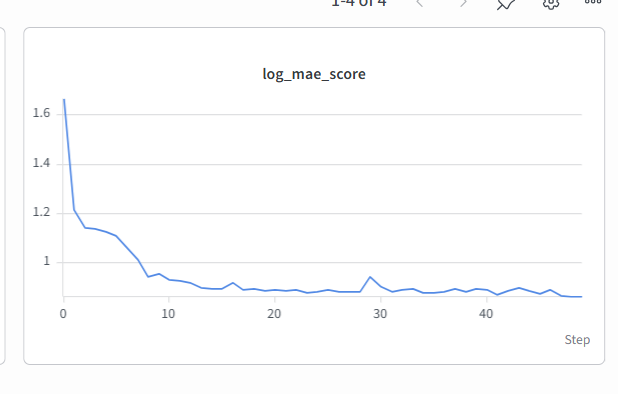

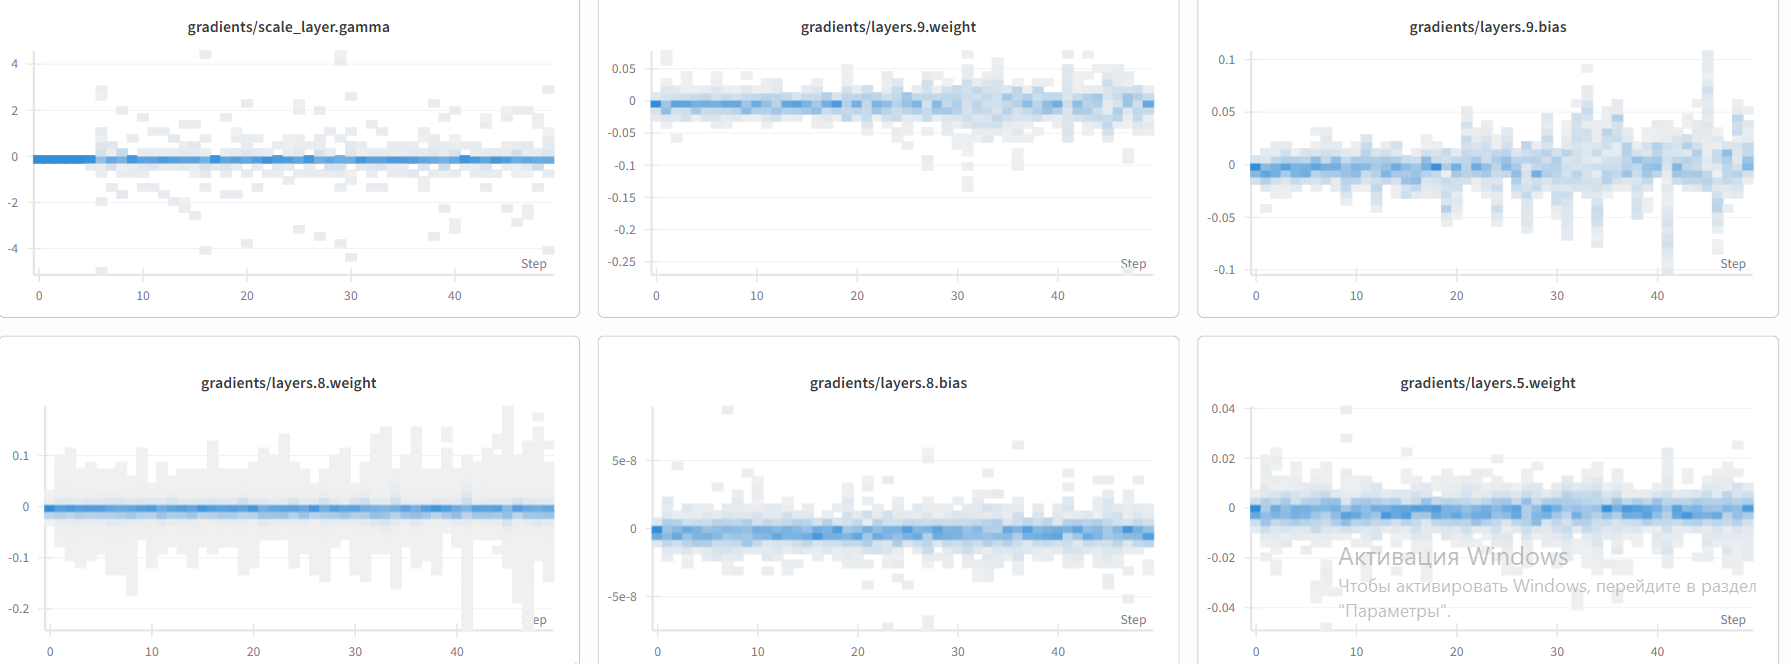

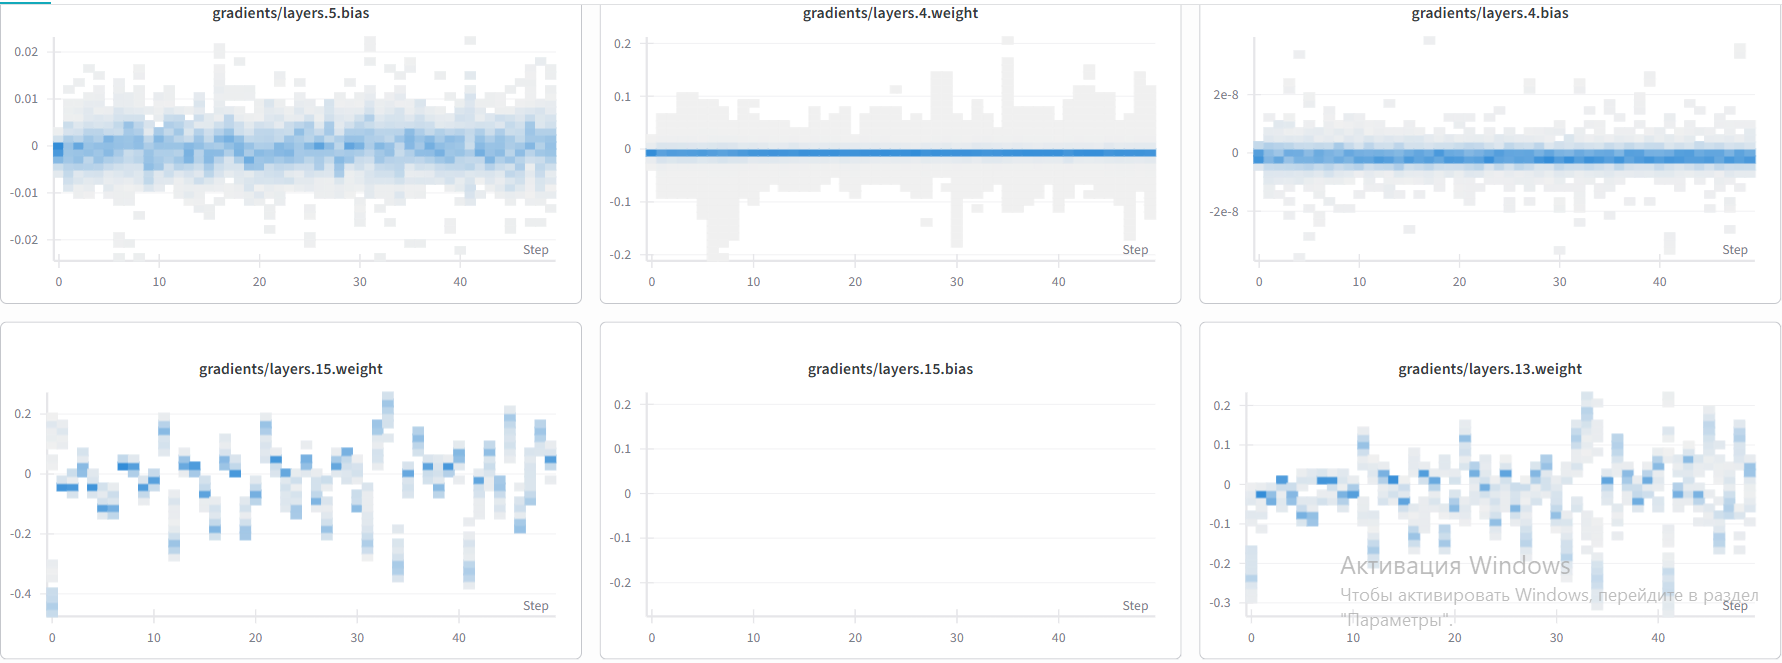

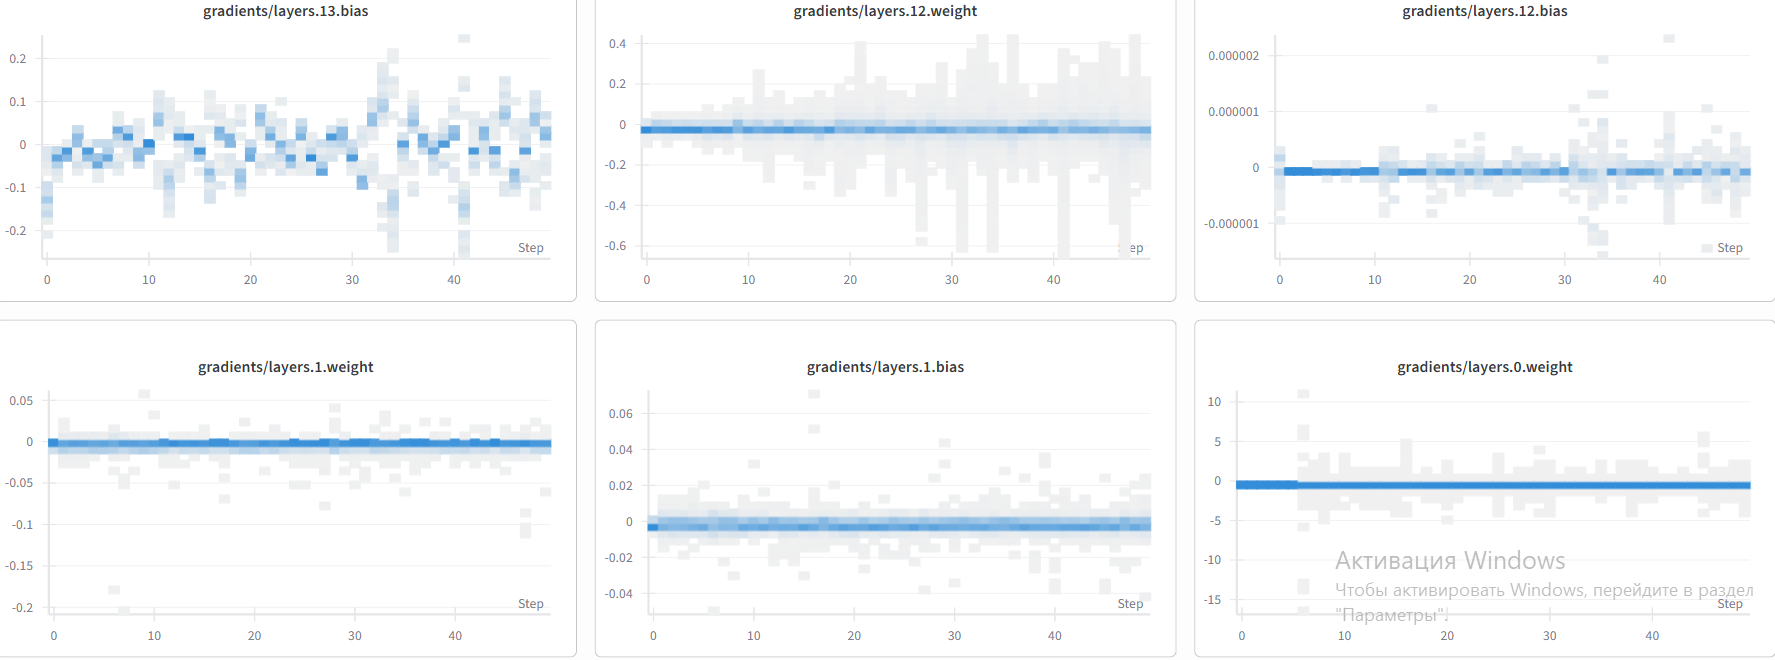

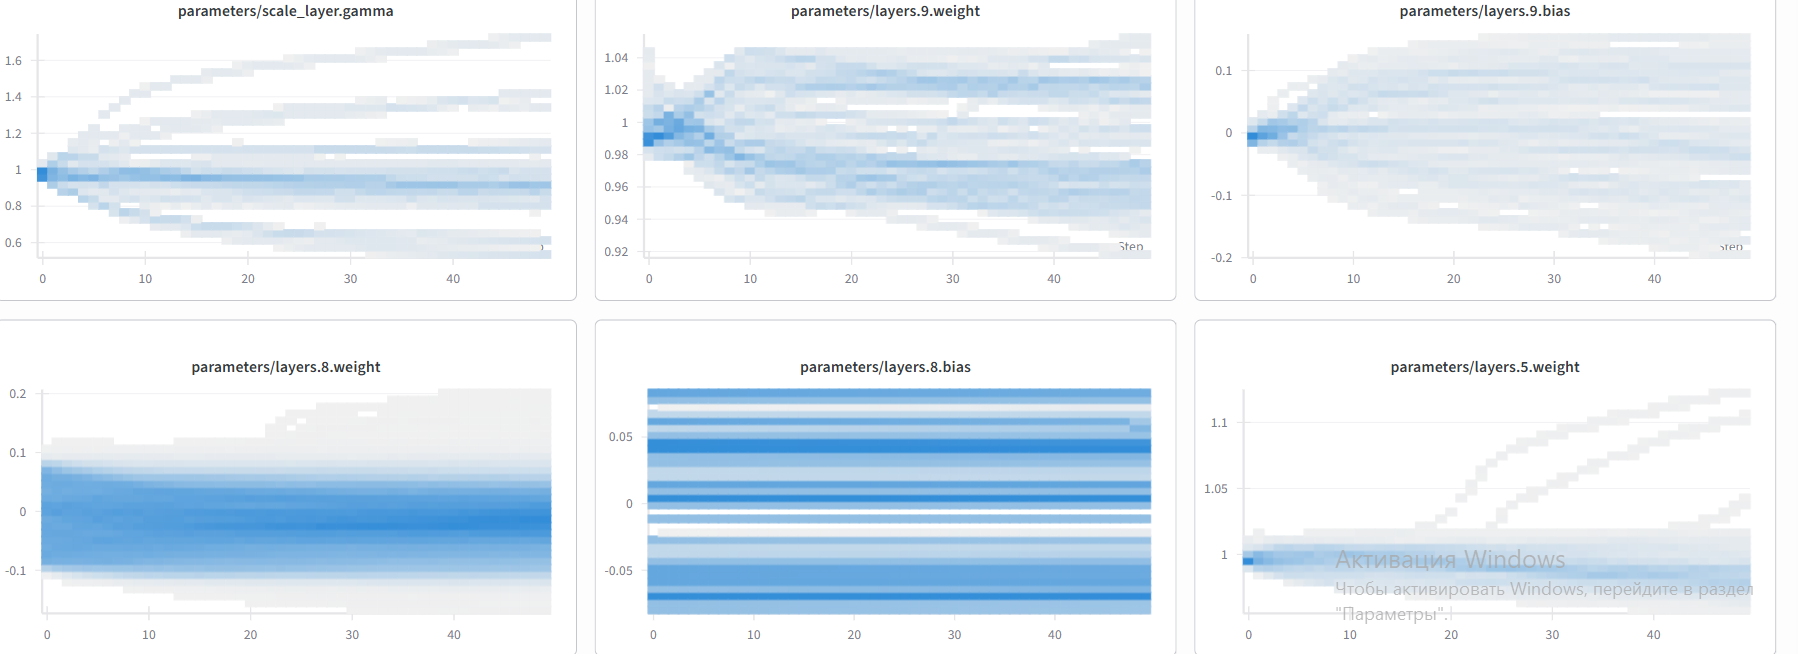

In [35]:
test_raw = pd.read_csv("/kaggle/input/datasets/annaakhlamova/test-from-user/test.csv")
first_coord_test = test_raw.merge(structures,left_on=["molecule_name", "atom_index_0"],right_on=["molecule_name", "atom_index"],how="left").rename(columns={"atom": "atom_0", "x": "x0", "y": "y0", "z": "z0"})
test_df = first_coord_test.merge(structures,left_on=["molecule_name", "atom_index_1"],right_on=["molecule_name", "atom_index"],how="left").rename(columns={"atom": "atom_1", "x": "x1", "y": "y1", "z": "z1"})
test_df["dist"] = np.sqrt((test_df["x1"] - test_df["x0"]) ** 2 + (test_df["y1"] - test_df["y0"]) ** 2 + (test_df["z1"] - test_df["z0"]) ** 2)
test_df["inv_dist"] = 1.0 / test_df["dist"]
test_df["inv_dist2"] = 1.0 / (test_df["dist"] ** 2)
test_df["inv_dist3"] = 1.0 / (test_df["dist"] ** 3)
test_df["inv_dist6"] = 1.0 / (test_df["dist"] ** 6)

test_df["en_0"] = test_df["atom_0"].map(electronegativity)
test_df["en_1"] = test_df["atom_1"].map(electronegativity)
test_df["en_diff"] = np.abs(test_df["en_0"] - test_df["en_1"])

In [36]:
X_test_encoded = pd.get_dummies(test_df[feature_cols])
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
X_test_scaled = scaler.transform(X_test_encoded.values)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

model.eval()
with torch.no_grad():
    test_preds = model(X_test_tensor.to(device)).numpy().reshape(-1)

submission = pd.DataFrame({
    'id': test_df['id'],
    'scalar_coupling_constant': test_preds})
submission.to_csv("submission.csv", index=False)
submission.head()

,id,scalar_coupling_constant
0,4658147,0.109606
1,4658148,165.243729
2,4658149,6.249127
3,4658150,163.591492
4,4658151,-0.101859


In [37]:
!kaggle competitions submit -c champs-scalar-coupling -f submission.csv -m "custom model"

100%|██████████████████████████████████████| 43.2M/43.2M [00:00<00:00, 48.2MB/s]
Successfully submitted to Predicting Molecular Properties